In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Solar_Energy_Production.csv")
df['date'] = pd.to_datetime(df.date, format="%Y/%m/%d %I:%M:%S %p")
df = df.set_index("date", drop=False)
display(df)

,name,id,address,date,kWh,public_url,installationDate,uid
date,,,,,,,,
2017-09-11 08:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 08:00:00,1.130,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 08:00:00
2017-09-11 09:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 09:00:00,2.340,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 09:00:00
2017-09-11 10:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 10:00:00,3.656,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 10:00:00
2017-09-11 11:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 11:00:00,4.577,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 11:00:00
2017-09-11 12:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 12:00:00,6.506,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 12:00:00
...,...,...,...,...,...,...,...,...
2023-03-12 15:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 15:00:00,201.285,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 15:00:00
2023-03-12 16:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 16:00:00,162.582,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 16:00:00
2023-03-12 17:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 17:00:00,107.060,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 17:00:00


In [ ]:
print(df.address.unique().size)

11


There are 11 distinct sites, identifiable with ID or address

In [ ]:
display(df.date.head(), df.date.tail())

,date
date,
2017-09-11 08:00:00,2017-09-11 08:00:00
2017-09-11 09:00:00,2017-09-11 09:00:00
2017-09-11 10:00:00,2017-09-11 10:00:00
2017-09-11 11:00:00,2017-09-11 11:00:00
2017-09-11 12:00:00,2017-09-11 12:00:00


,date
date,
2023-03-12 15:00:00,2023-03-12 15:00:00
2023-03-12 16:00:00,2023-03-12 16:00:00
2023-03-12 17:00:00,2023-03-12 17:00:00
2023-03-12 18:00:00,2023-03-12 18:00:00
2023-03-12 19:00:00,2023-03-12 19:00:00


It looks like time is continuous by the hour, however not all sites may have entries for a certain time, shown by the distribution on kaggle

Output is recorded as kWh produced in the timespan, shown on kaggle

In [ ]:
display(
    df.groupby("name").date.agg(start_date="min", end_date="max")
)

,start_date,end_date
name,,
Bearspaw Water Treatment Plant,2017-11-21 10:45:00,2023-03-16 19:00:00
CFD Firehall #7,2017-09-21 07:00:00,2023-03-16 19:00:00
Calgary Fire Hall Headquarters,2016-11-24 14:00:00,2023-03-16 19:00:00
City of Calgary North Corporate Warehouse,2016-12-23 09:30:00,2023-03-16 19:00:00
Glenmore Water Treatment Plant,2017-03-08 10:00:00,2023-03-12 17:00:00
Hillhurst Sunnyside Community Association,2016-10-03 13:00:00,2023-03-15 19:00:00
Manchester Building M,2017-10-05 13:15:00,2023-03-16 19:00:00
Richmond - Knob Hill Community Hall,2016-12-09 11:00:00,2023-03-16 19:00:00
Southland Leisure Centre,2015-09-01 14:30:00,2023-03-16 18:00:00


Looks like these sites have all been comissioned at slightly different times, and only one has been decomissioned early, in 2018.
Most others have data that stops at 03/2023.

In [ ]:
df['month'] = df.index.month
df['year'] = df.index.year

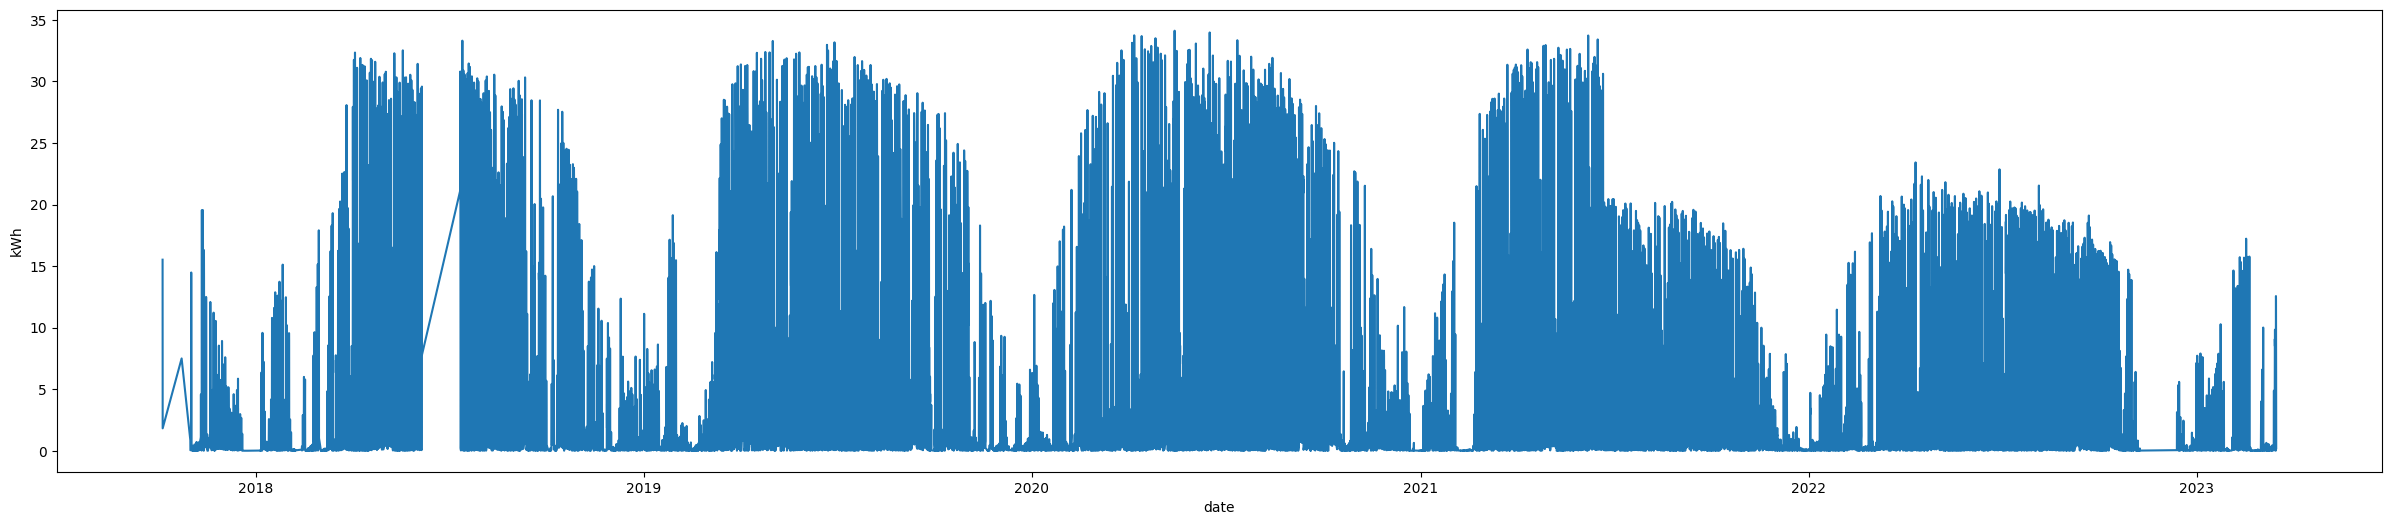

In [ ]:
plt.figure(figsize=(30, 6))
sns.lineplot(df[df.name == "Manchester Building M"], x="date", y="kWh")
plt.show()

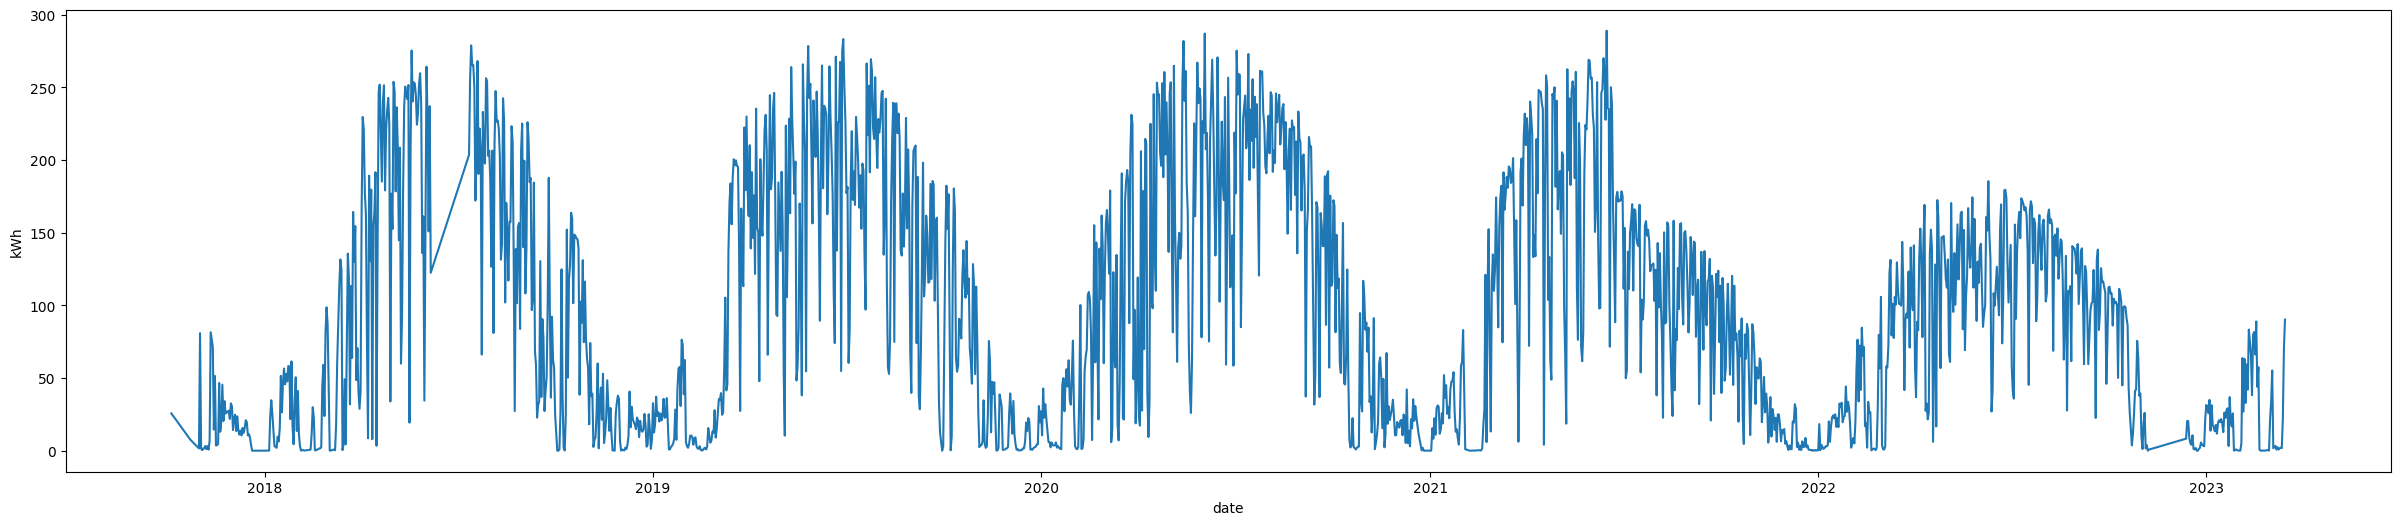

In [ ]:
df_by_day = df.groupby(["name", pd.Grouper(freq="D")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)

target = df_by_day.xs("Manchester Building M", level='name')

plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

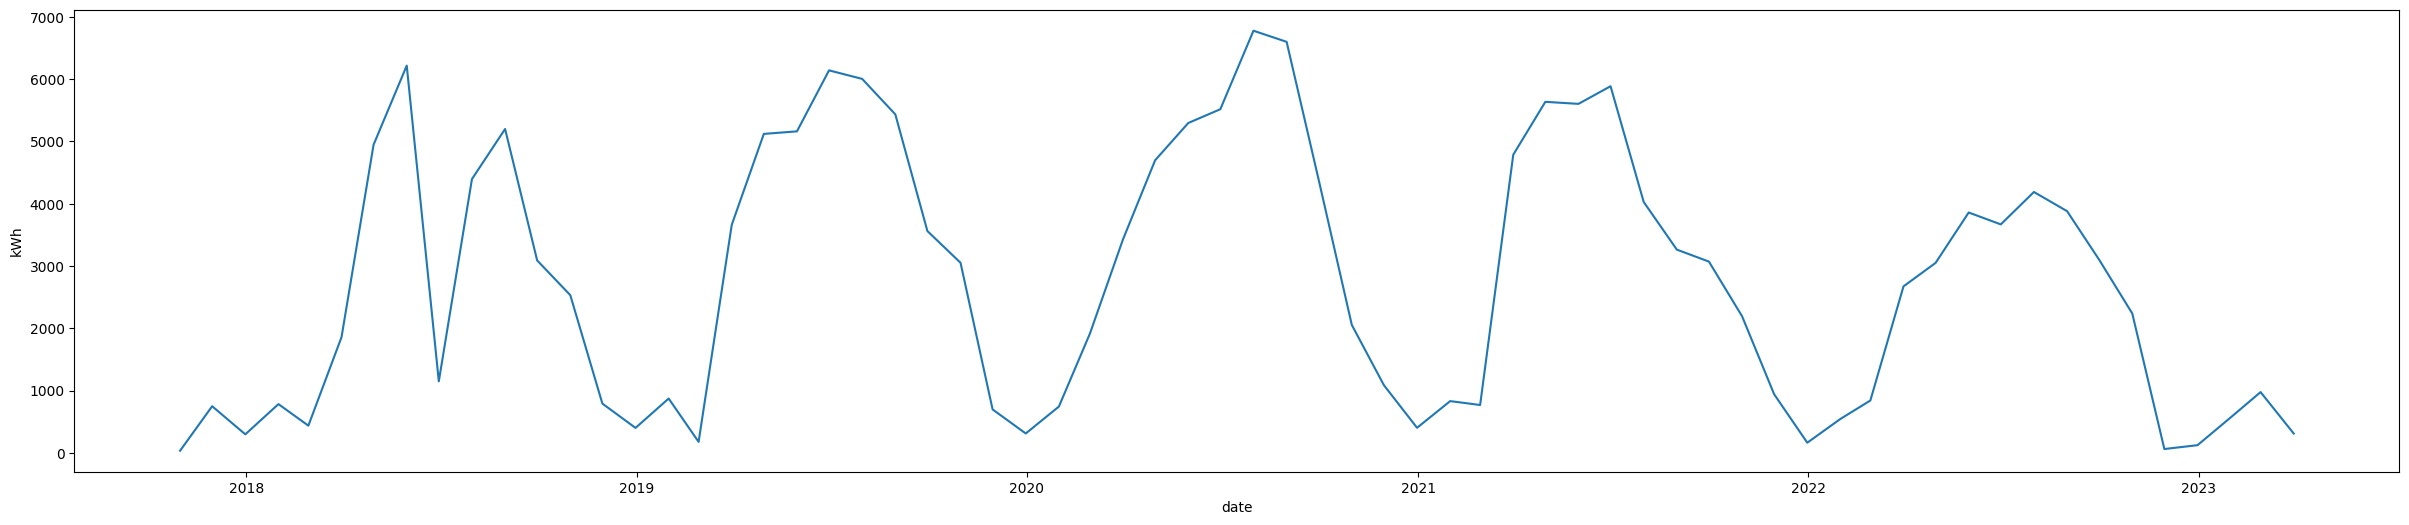

In [ ]:
df_by_month = df.groupby(["name", pd.Grouper(freq="ME")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)
target = df_by_month.xs("Manchester Building M", level='name')
plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

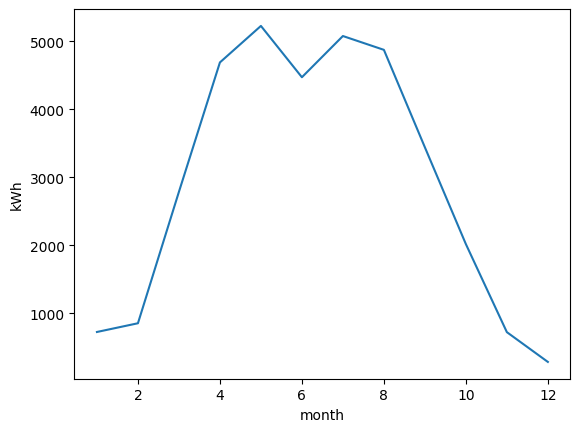

In [ ]:

target = df_by_month.xs("Manchester Building M", level = 'name')

target = target.groupby("month").mean()
sns.lineplot(data = target, x = 'month', y = 'kWh')
plt.show()

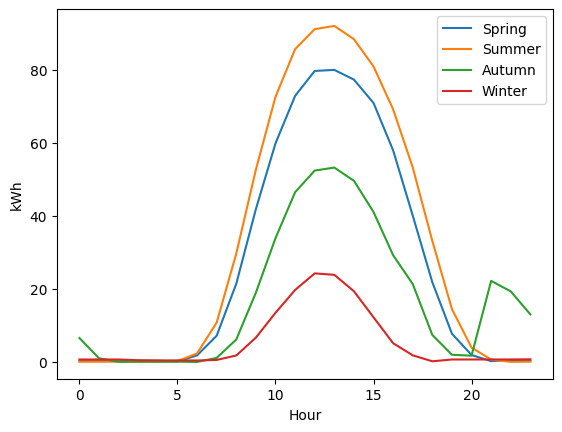

In [ ]:
df_spring = df[(df.month == 3) | (df.month == 4) | (df.month == 5)]
df_summer = df[(df.month == 6) | (df.month == 7) | (df.month == 8)]
df_autumn = df[(df.month == 9) | (df.month == 10) | (df.month == 11)]
df_winter = df[(df.month == 12) | (df.month == 1) | (df.month == 2)]

dfs = [df_spring, df_summer, df_autumn, df_winter]

target_spring = df_spring.groupby(df_spring.index.hour).agg(
    {'kWh': 'mean'}
)
target_summer = df_summer.groupby(df_summer.index.hour).agg(
    {'kWh': 'mean'}
)
target_autumn = df_autumn.groupby(df_autumn.index.hour).agg(
    {'kWh': 'mean'}
)
target_winter = df_winter.groupby(df_winter.index.hour).agg(
    {'kWh': 'mean'}
)

targets = [target_spring, target_summer, target_autumn, target_winter]

for index, season in enumerate(targets):
    sns.lineplot(data=season, x=season.index, y='kWh', label=['Spring', 'Summer', 'Autumn', 'Winter'][index])

plt.xlabel("Hour")

plt.legend()
plt.show()